# Geological Variability → Production Variability  
## Spatial Map Study – 10 Fields × 100 × 100 Grid Points

Each field covers a **10 × 10 mile** area sampled on a regular **0.1-mile grid** (10,000 points/field, 100,000 total).  
Geological features are generated as spatially correlated **Gaussian Random Fields** (GRF via FFT).

| Feature | Unit | Base value |
|---|---|---|
| Structural Depth | ft TVDSS | 9,000 |
| Isopach (net pay) | ft | 80 |
| Gamma Ray | API | 45 |
| Resistivity | ohm·m | 15 |
| Porosity | fraction | 0.18 |
| **Oil Production** | BOPD | derived |

**Field 1** = highest variability & shortest correlation length  
**Field 10** = lowest variability & longest correlation length


## 1. Imports & Configuration

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from scipy import stats
import warnings
warnings.filterwarnings("ignore")

plt.rcParams.update({"figure.dpi": 130, "font.family": "DejaVu Sans",
                     "axes.titlesize": 10, "axes.labelsize": 9})
print("Libraries loaded OK")


Libraries loaded OK


## 2. Synthetic Data Generation – Gaussian Random Fields

In [7]:
np.random.seed(42)

N_FIELDS   = 10
GRID_N     = 100
FIELD_SIZE = 10.0

xs = np.linspace(0, FIELD_SIZE, GRID_N)
ys = np.linspace(0, FIELD_SIZE, GRID_N)
XX, YY = np.meshgrid(xs, ys)
x_flat, y_flat = XX.ravel(), YY.ravel()

var_scale = np.linspace(1.0, 0.1, N_FIELDS)

BASE = {"Structural_Depth_ft": 9000, "Isopach_ft": 80,
        "GammaRay_API": 45, "Resistivity_ohmm": 15, "Porosity_frac": 0.18}
CV   = {"Structural_Depth_ft": 0.12, "Isopach_ft": 0.35,
        "GammaRay_API": 0.30, "Resistivity_ohmm": 0.45, "Porosity_frac": 0.25}

def grf(length_scale, n=GRID_N):
    freq = np.fft.fftfreq(n)
    fx, fy = np.meshgrid(freq, freq)
    psd = np.exp(-0.5 * ((fx**2 + fy**2) / (1.0 / (n * length_scale))**2))
    psd[0, 0] = 0
    noise = np.fft.ifft2(np.fft.fft2(np.random.randn(n, n)) * np.sqrt(psd)).real
    return ((noise - noise.mean()) / (noise.std() + 1e-12)).ravel()

all_dfs = []
for f_idx in range(N_FIELDS):
    fnum = f_idx + 1
    vs   = var_scale[f_idx]
    ls   = max(0.03, 0.25 - 0.02 * f_idx)

    depth = np.clip(BASE["Structural_Depth_ft"] * (1 + CV["Structural_Depth_ft"]*vs*grf(ls)), 5000, 15000)
    iso   = np.clip(BASE["Isopach_ft"]          * (1 + CV["Isopach_ft"]         *vs*grf(ls)), 5, 300)
    gr    = np.clip(BASE["GammaRay_API"]         * (1 + CV["GammaRay_API"]       *vs*grf(ls)), 10, 150)
    res   = np.clip(BASE["Resistivity_ohmm"]     * np.exp(CV["Resistivity_ohmm"] *vs*grf(ls)), 1, 200)
    phi   = np.clip(BASE["Porosity_frac"]        * (1 + CV["Porosity_frac"]      *vs*grf(ls)), 0.02, 0.40)
    q_base = (phi * iso * res) / (depth / 10000)
    q      = np.clip(q_base * (1 + (0.10 + 0.30*vs)*grf(ls)), 10, None)

    all_dfs.append(pd.DataFrame({
        "Field": "Field_{:02d}".format(fnum),
        "Field_Variability_Rank": fnum,
        "X_miles": np.round(x_flat, 2),
        "Y_miles": np.round(y_flat, 2),
        "Structural_Depth_ft":  np.round(depth, 1),
        "Isopach_ft":           np.round(iso,   1),
        "GammaRay_API":         np.round(gr,    1),
        "Resistivity_ohmm":     np.round(res,   2),
        "Porosity_frac":        np.round(phi,   4),
        "Oil_Production_BOPD":  np.round(q,     1),
    }))

df = pd.concat(all_dfs, ignore_index=True)
print("Dataset: {:,} rows x {} columns".format(df.shape[0], df.shape[1]))
df.head()


Dataset: 100,000 rows x 10 columns


,Field,Field_Variability_Rank,X_miles,Y_miles,Structural_Depth_ft,Isopach_ft,GammaRay_API,Resistivity_ohmm,Porosity_frac,Oil_Production_BOPD
0,Field_01,1,0.0,0.0,10002.2,107.9,45.7,7.89,0.2231,176.3
1,Field_01,1,0.1,0.0,10279.1,94.3,40.4,7.68,0.2219,164.4
2,Field_01,1,0.2,0.0,10521.3,81.3,35.4,8.27,0.2195,170.7
3,Field_01,1,0.3,0.0,10739.9,71.4,30.4,9.70,0.2169,196.7
4,Field_01,1,0.4,0.0,10941.8,65.9,25.2,11.72,0.2152,241.6


## 3. Helper – Reshape to 2-D Grid

In [8]:
def to_grid(df_field, col):
    return df_field.pivot(index="Y_miles", columns="X_miles", values=col).values

GEO_CMAPS = {
    "Structural_Depth_ft":  "viridis_r",
    "Isopach_ft":           "YlOrBr",
    "GammaRay_API":         "RdYlGn_r",
    "Resistivity_ohmm":     "plasma",
    "Porosity_frac":        "Blues",
    "Oil_Production_BOPD":  "hot_r",
}
LABELS = {
    "Structural_Depth_ft":  "Depth (ft)",
    "Isopach_ft":           "Isopach (ft)",
    "GammaRay_API":         "Gamma Ray (API)",
    "Resistivity_ohmm":     "Resistivity (ohm-m)",
    "Porosity_frac":        "Porosity (frac)",
    "Oil_Production_BOPD":  "Production (BOPD)",
}
features = list(GEO_CMAPS.keys())
print("Helpers ready")


Helpers ready


## 4. Feature Maps – Field 1 vs. Field 10

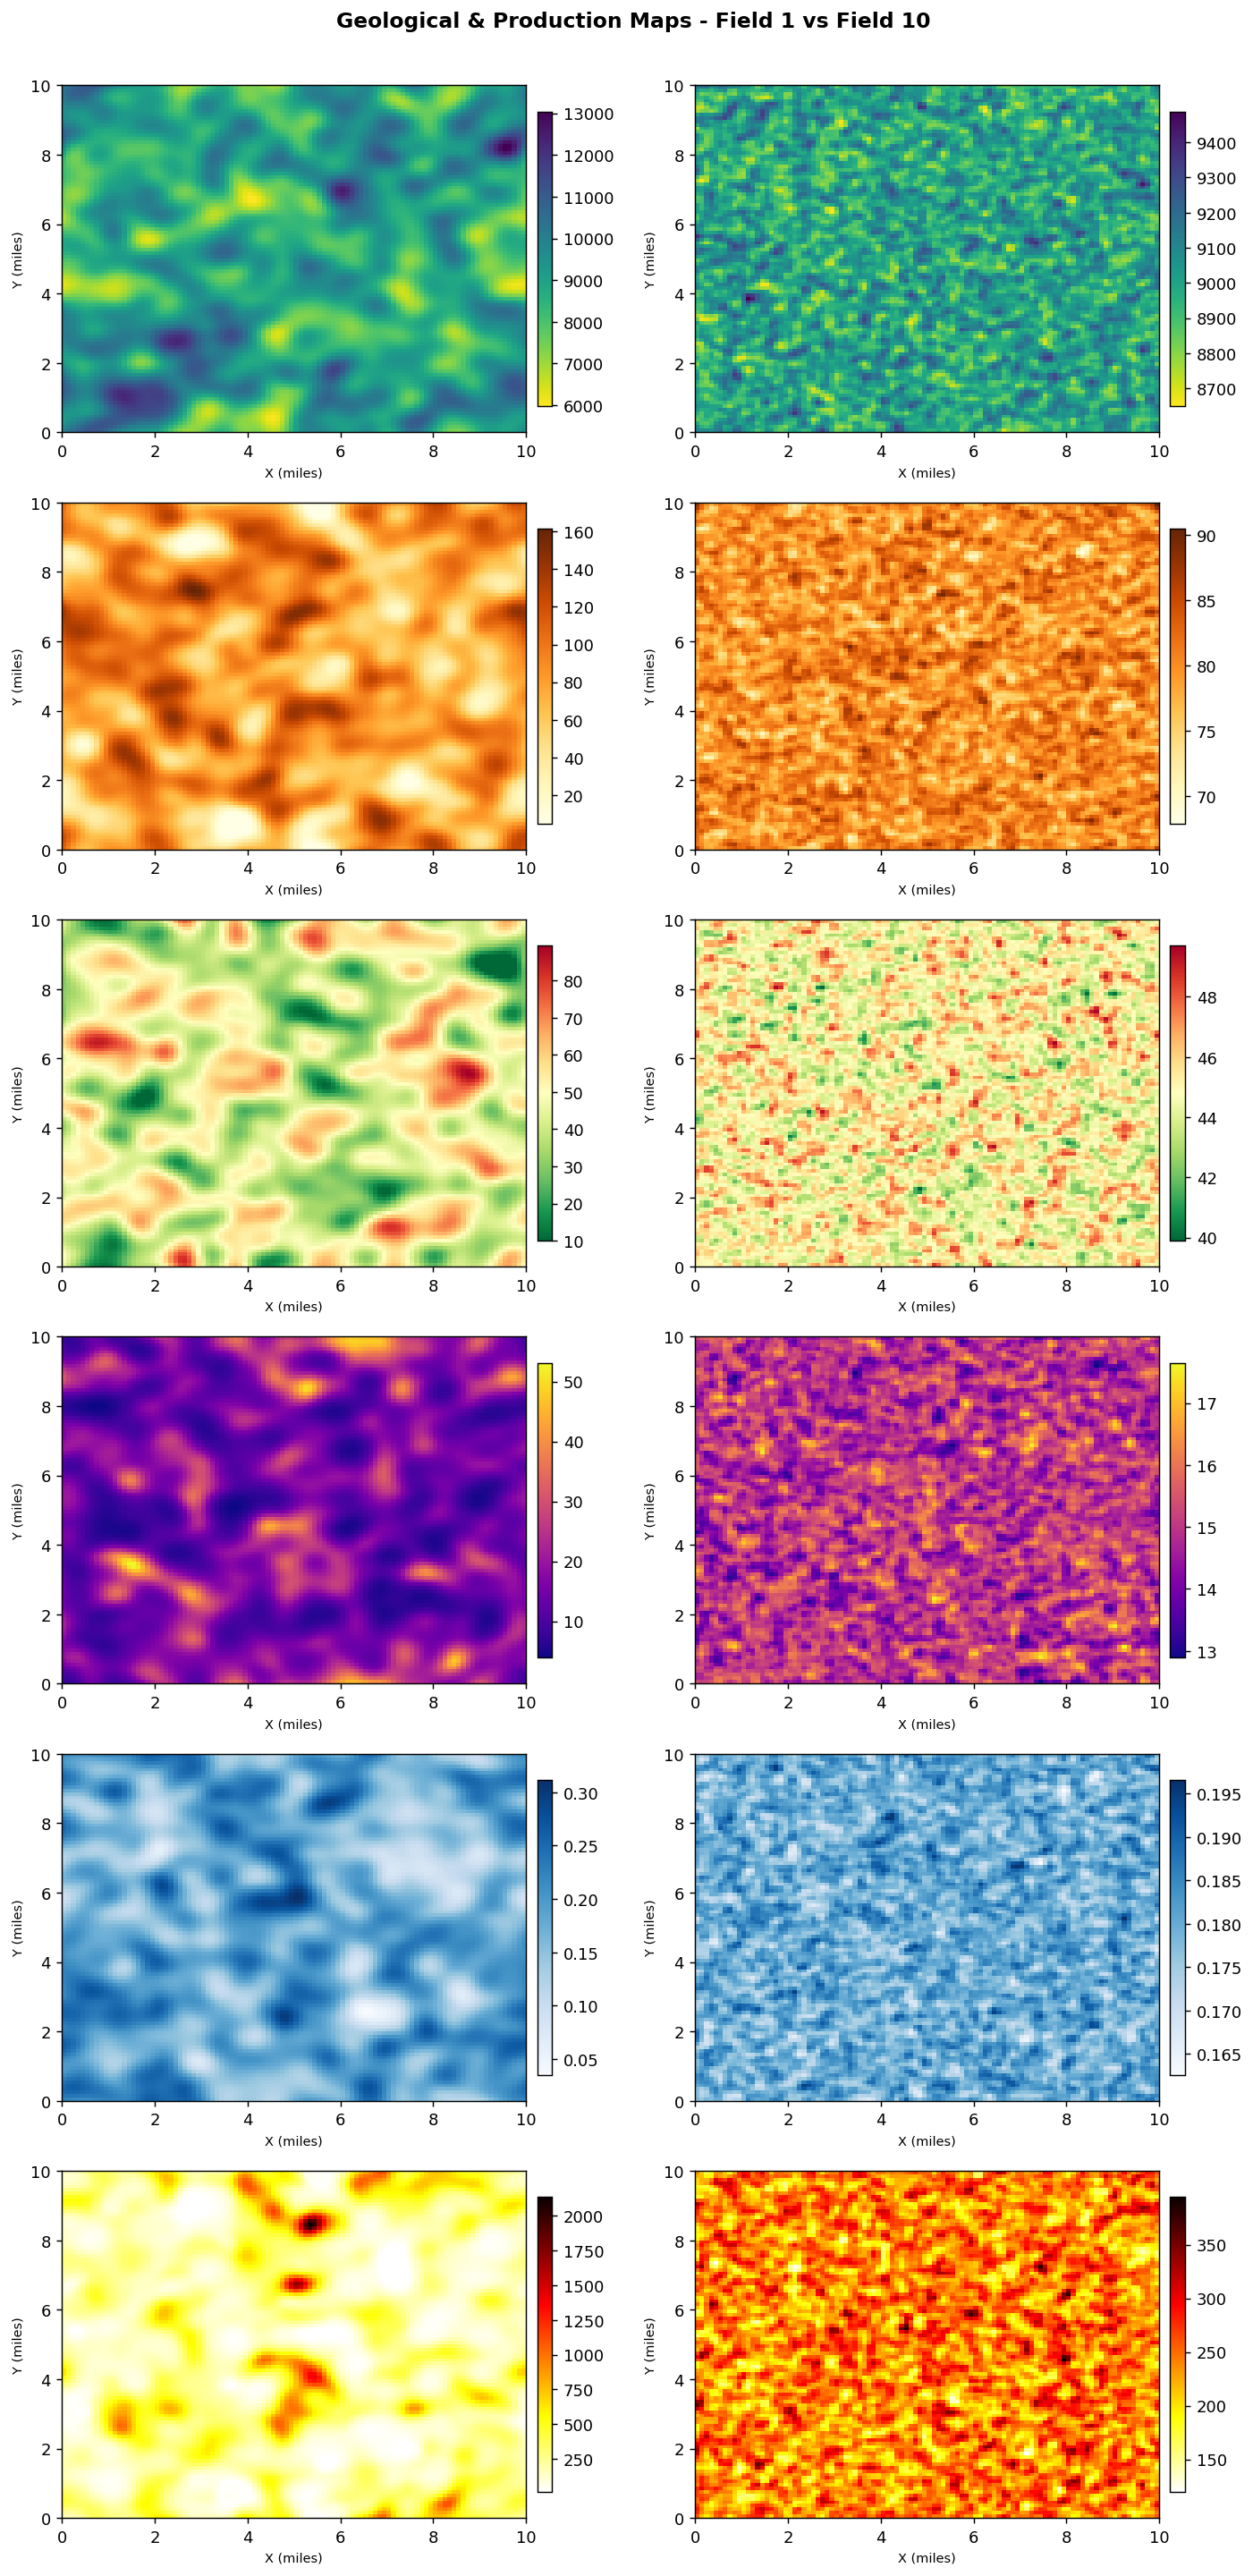

In [9]:
fig, axes = plt.subplots(6, 2, figsize=(11, 22))

for row_i, feat in enumerate(features):
    for col_i, fnum in enumerate([1, 10]):
        ax = axes[row_i, col_i]
        sub  = df[df["Field_Variability_Rank"] == fnum]
        grid = to_grid(sub, feat)
        im   = ax.imshow(grid, origin="lower", cmap=GEO_CMAPS[feat],
                         extent=[0, 10, 0, 10], aspect="auto")
        plt.colorbar(im, ax=ax, shrink=0.85, pad=0.02)
        var_label = "High Var" if fnum == 1 else "Low Var"
        field_label = "Field {:02d} - {}".format(fnum, var_label)
#         ax.set_title("{}
# {}".format(LABELS[feat], field_label), fontsize=9, fontweight="bold")
        ax.set_xlabel("X (miles)", fontsize=8)
        ax.set_ylabel("Y (miles)", fontsize=8)

fig.suptitle("Geological & Production Maps - Field 1 vs Field 10",
             fontsize=13, fontweight="bold", y=1.005)
plt.tight_layout()
plt.show()


## 5. Oil Production Map – All 10 Fields

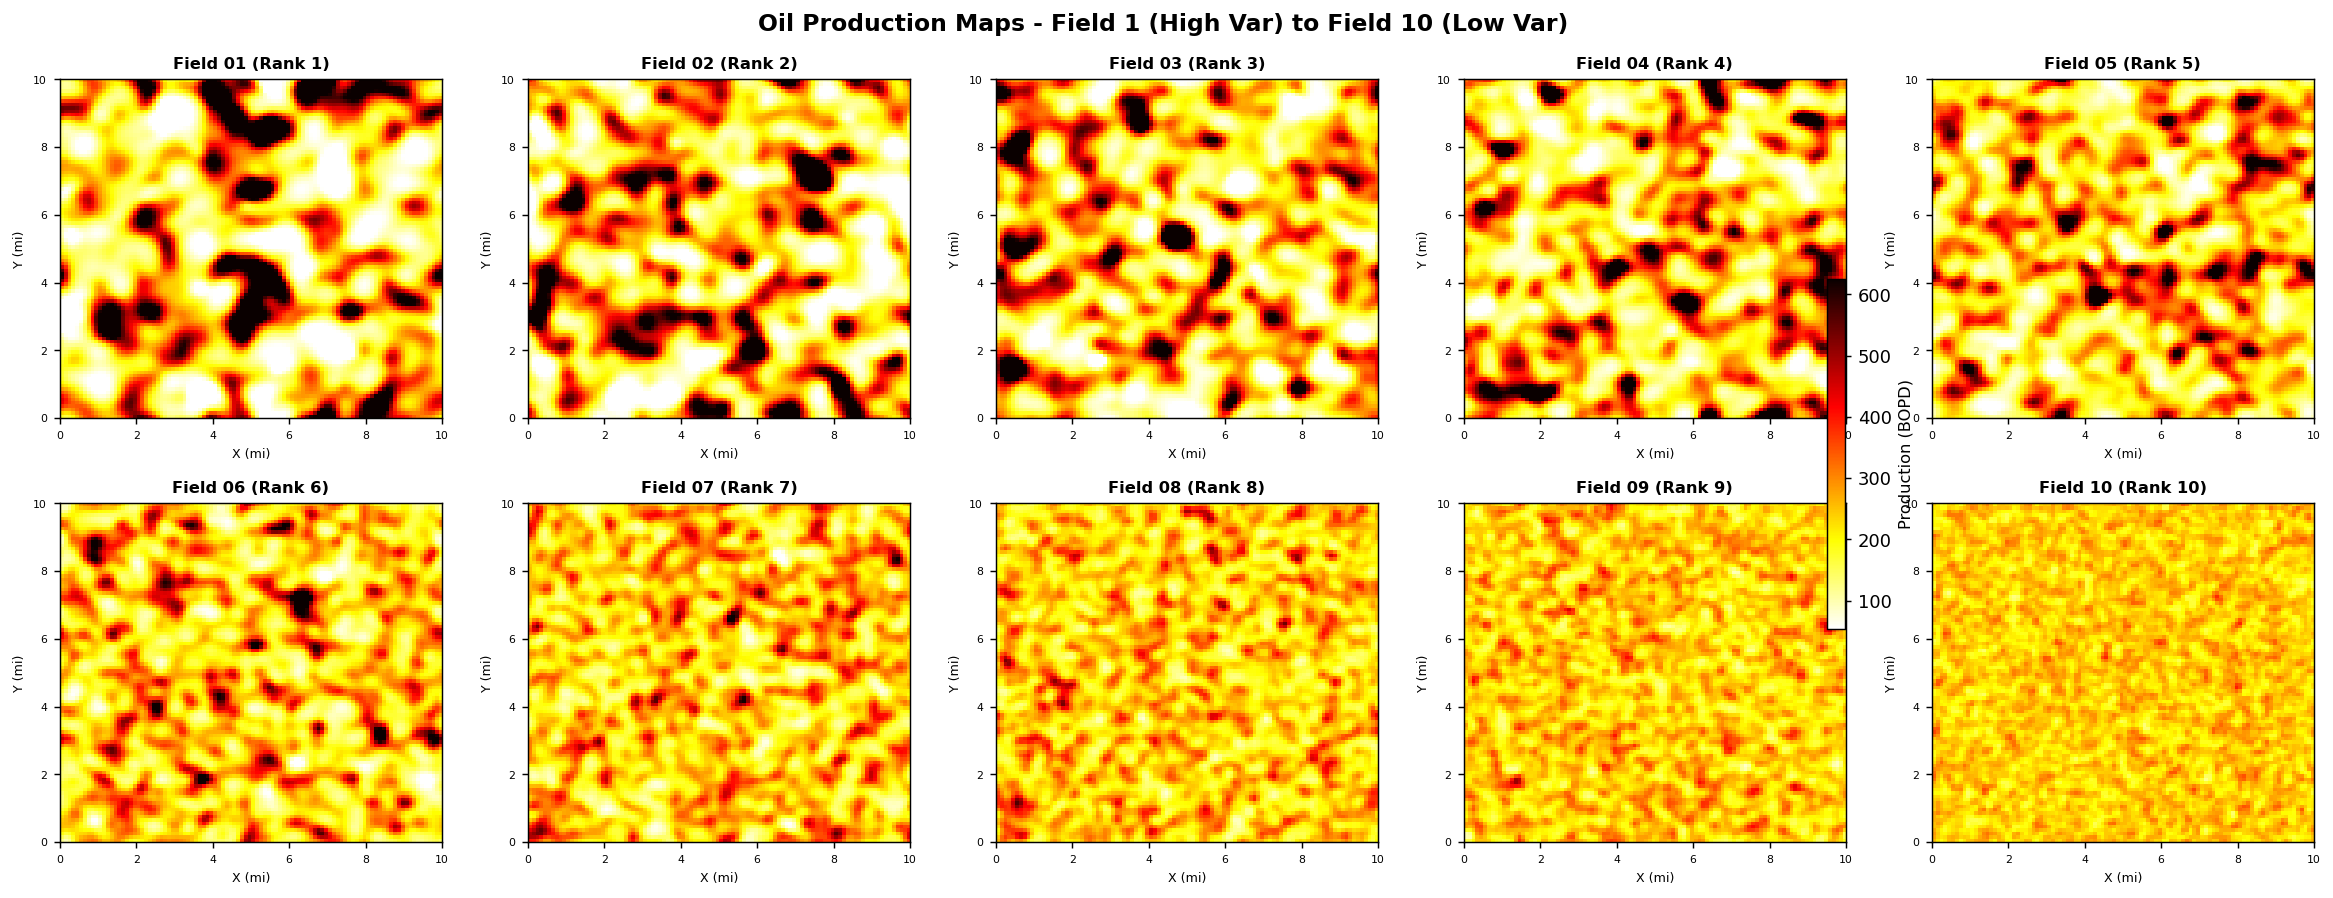

In [10]:
fig, axes = plt.subplots(2, 5, figsize=(18, 7))
axes = axes.flatten()

all_prod = df["Oil_Production_BOPD"].values
vmin = np.percentile(all_prod, 2)
vmax = np.percentile(all_prod, 98)

for ax, fnum in zip(axes, range(1, 11)):
    sub  = df[df["Field_Variability_Rank"] == fnum]
    grid = to_grid(sub, "Oil_Production_BOPD")
    im   = ax.imshow(grid, origin="lower", cmap="hot_r",
                     extent=[0, 10, 0, 10], aspect="auto", vmin=vmin, vmax=vmax)
    ax.set_title("Field {:02d} (Rank {})".format(fnum, fnum), fontsize=9, fontweight="bold")
    ax.set_xlabel("X (mi)", fontsize=7)
    ax.set_ylabel("Y (mi)", fontsize=7)
    ax.tick_params(labelsize=6)

fig.colorbar(im, ax=axes.tolist(), label="Production (BOPD)", shrink=0.5)
fig.suptitle("Oil Production Maps - Field 1 (High Var) to Field 10 (Low Var)",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()


## 6. Spatial Variograms – Porosity

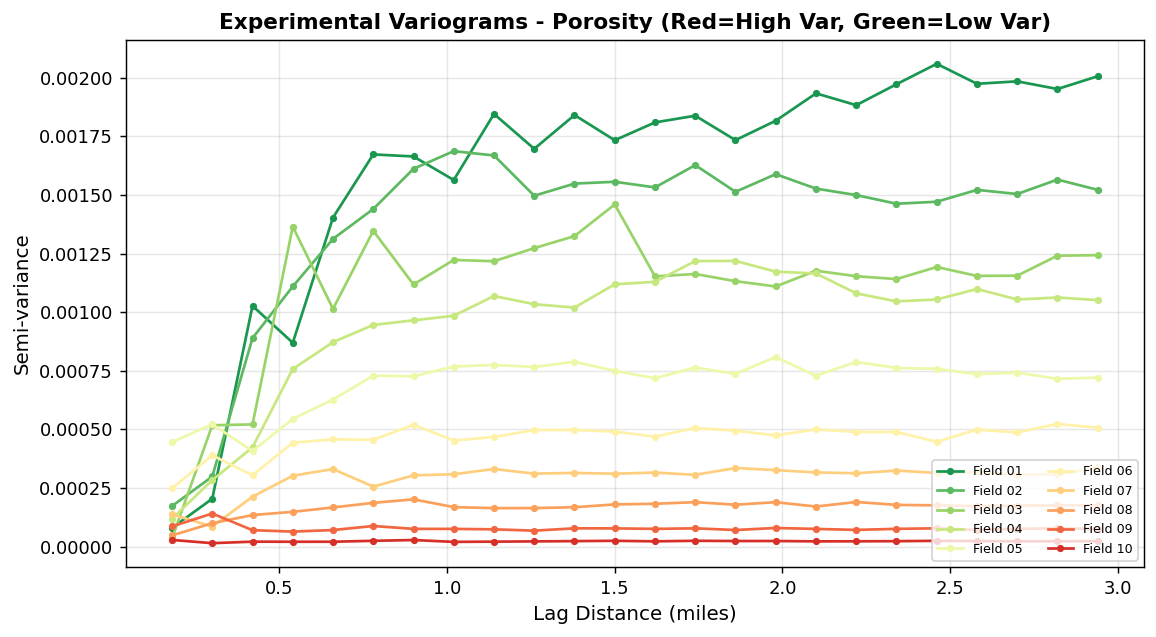

In [11]:
def experimental_variogram(df_field, col, n_lags=25, max_dist=3.0):
    sub = df_field.sample(min(500, len(df_field)), random_state=0)
    x = sub["X_miles"].values
    y = sub["Y_miles"].values
    z = sub[col].values
    lags = np.linspace(0, max_dist, n_lags + 1)
    h_list, g_list = [], []
    for i in range(len(x)):
        d   = np.sqrt((x[i] - x)**2 + (y[i] - y)**2)
        dz2 = (z[i] - z)**2
        for k in range(n_lags):
            mask = (d >= lags[k]) & (d < lags[k+1])
            if mask.sum() > 3:
                g_list.append(dz2[mask].mean() / 2)
                h_list.append((lags[k] + lags[k+1]) / 2)
    hh = np.array(h_list)
    gg = np.array(g_list)
    bins = np.linspace(0, max_dist, n_lags + 1)
    hbin, gbin = [], []
    for k in range(n_lags):
        m = (hh >= bins[k]) & (hh < bins[k+1])
        if m.sum() > 0:
            hbin.append(hh[m].mean())
            gbin.append(gg[m].mean())
    return np.array(hbin), np.array(gbin)

fig, ax = plt.subplots(figsize=(9, 5))
palette = cm.RdYlGn_r(np.linspace(0.1, 0.9, N_FIELDS))
for fnum, color in zip(range(1, 11), palette):
    sub = df[df["Field_Variability_Rank"] == fnum]
    h, g = experimental_variogram(sub, "Porosity_frac")
    ax.plot(h, g, marker="o", markersize=3, linewidth=1.5, color=color,
            label="Field {:02d}".format(fnum))

ax.set_xlabel("Lag Distance (miles)", fontsize=11)
ax.set_ylabel("Semi-variance", fontsize=11)
ax.set_title("Experimental Variograms - Porosity (Red=High Var, Green=Low Var)",
             fontsize=12, fontweight="bold")
ax.legend(fontsize=7, ncol=2, loc="lower right")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


## 7. CV Trends Across Fields

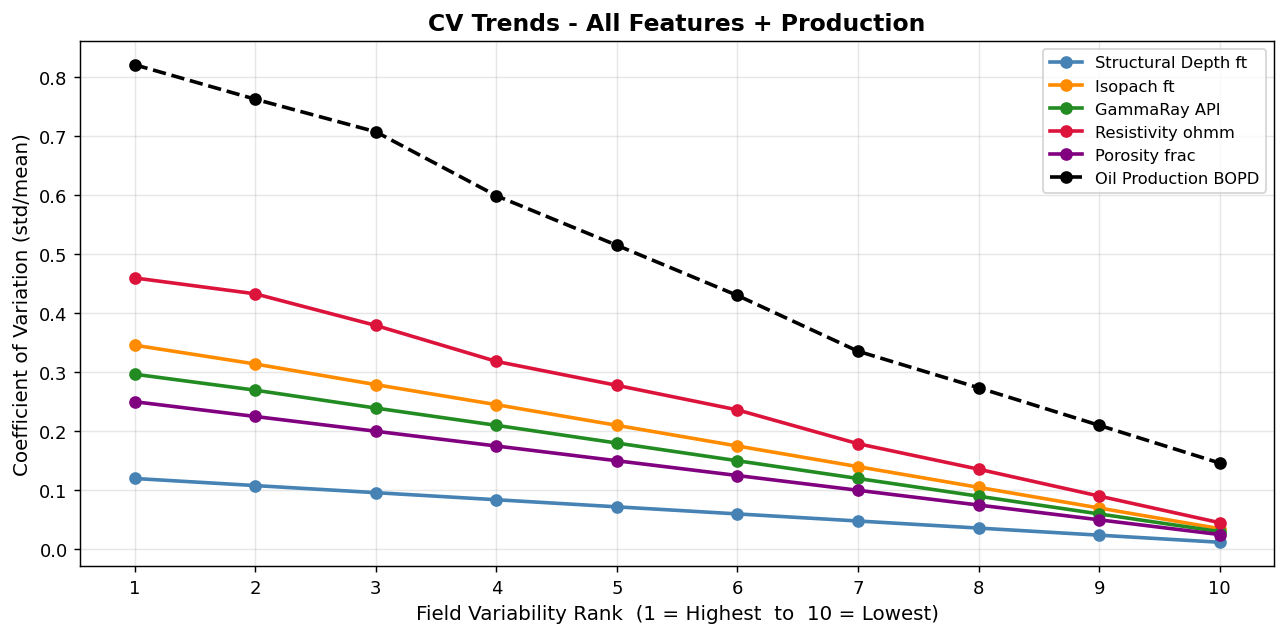

In [12]:
colors_map = {
    "Structural_Depth_ft":  "steelblue",
    "Isopach_ft":           "darkorange",
    "GammaRay_API":         "forestgreen",
    "Resistivity_ohmm":     "crimson",
    "Porosity_frac":        "purple",
    "Oil_Production_BOPD":  "black",
}

fig, ax = plt.subplots(figsize=(10, 5))
for feat in features:
    cv_vals = [
        df[df["Field_Variability_Rank"] == i][feat].std() /
        df[df["Field_Variability_Rank"] == i][feat].mean()
        for i in range(1, 11)
    ]
    ls = "--" if feat == "Oil_Production_BOPD" else "-"
    ax.plot(range(1, 11), cv_vals, marker="o", lw=2.0, ls=ls,
            color=colors_map[feat], label=feat.replace("_", " "))

ax.set_xlabel("Field Variability Rank  (1 = Highest  to  10 = Lowest)", fontsize=11)
ax.set_ylabel("Coefficient of Variation (std/mean)", fontsize=11)
ax.set_title("CV Trends - All Features + Production", fontsize=13, fontweight="bold")
ax.set_xticks(range(1, 11))
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


## 8. Production Profiles at Y = 5 miles

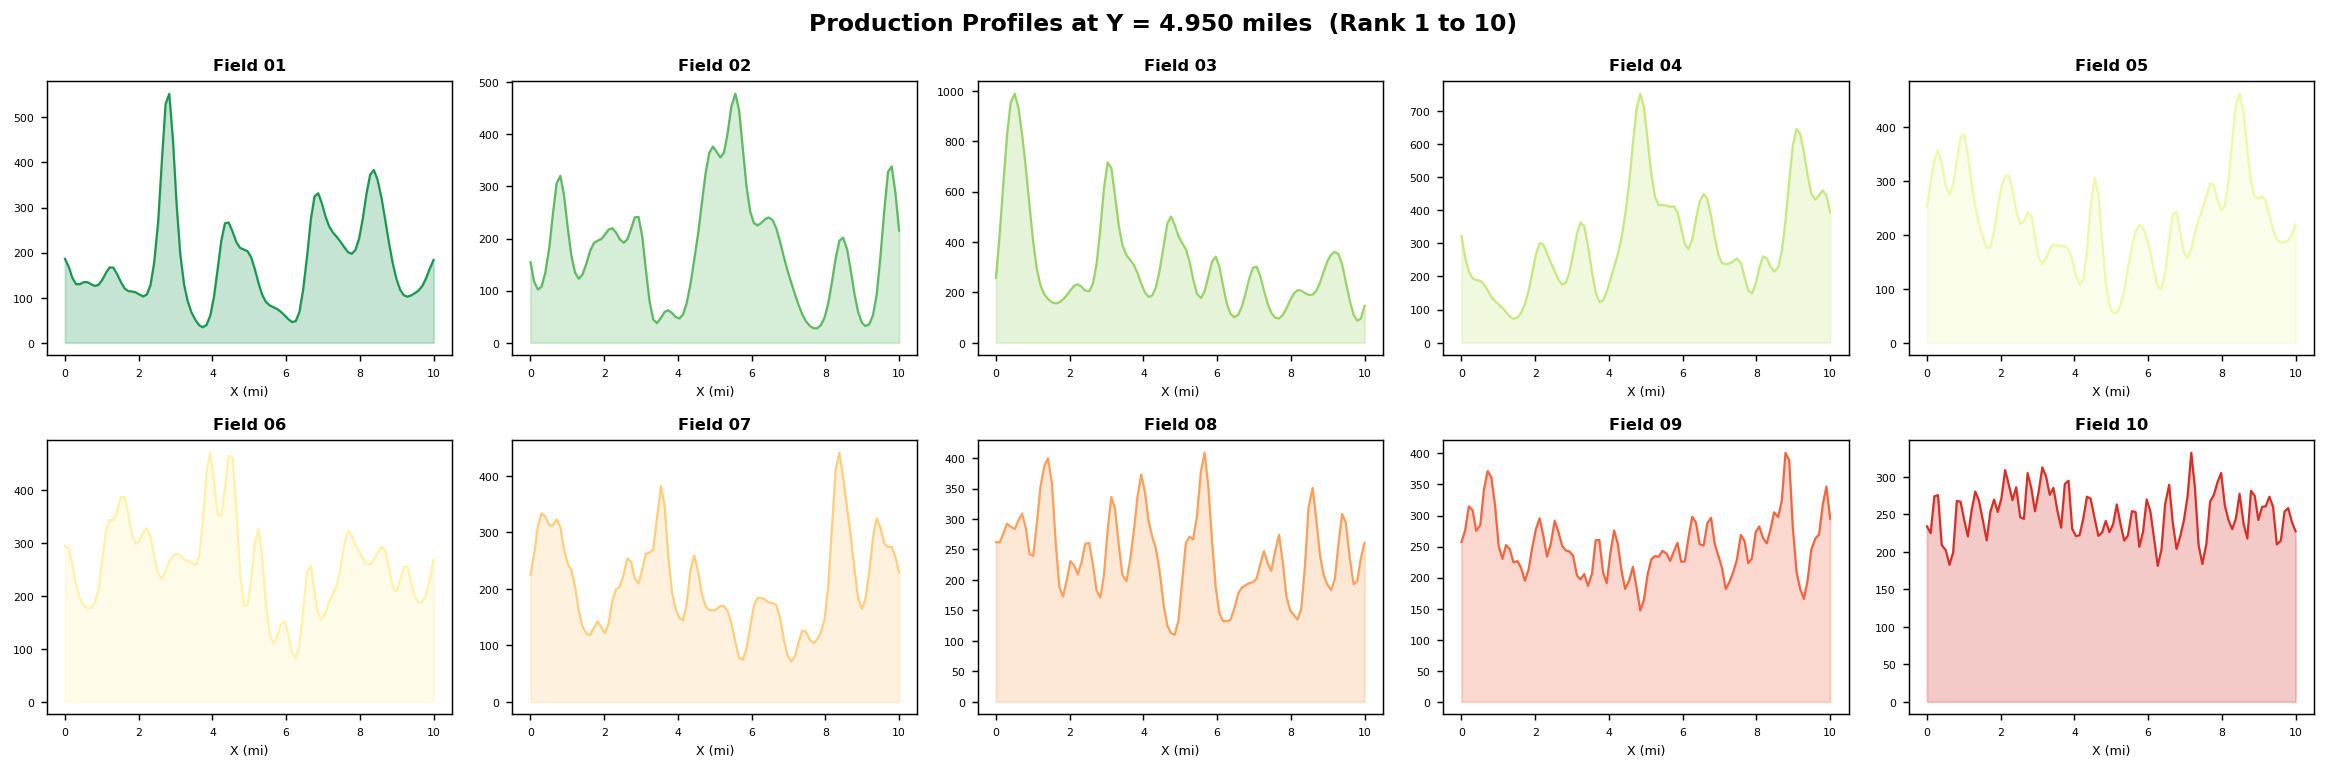

In [13]:
fig, axes = plt.subplots(2, 5, figsize=(18, 6), sharey=False)
axes = axes.flatten()
palette2 = cm.RdYlGn_r(np.linspace(0.1, 0.9, N_FIELDS))

# Snap to nearest available Y value to 5.0 (linspace never lands exactly on 5.0)
y_vals = np.sort(df["Y_miles"].unique())
y_mid  = y_vals[np.argmin(np.abs(y_vals - 5.0))]

for ax, fnum, color in zip(axes, range(1, 11), palette2):
    sub = df[(df["Field_Variability_Rank"] == fnum) & (df["Y_miles"] == y_mid)].sort_values("X_miles")
    ax.plot(sub["X_miles"], sub["Oil_Production_BOPD"], color=color, lw=1.2)
    ax.fill_between(sub["X_miles"], sub["Oil_Production_BOPD"], alpha=0.25, color=color)
    ax.set_title("Field {:02d}".format(fnum), fontsize=9, fontweight="bold")
    ax.set_xlabel("X (mi)", fontsize=7)
    ax.tick_params(labelsize=6)

fig.suptitle("Production Profiles at Y = {:.3f} miles  (Rank 1 to 10)".format(y_mid),
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()


## 9. Mean Geological CV vs. Production CV

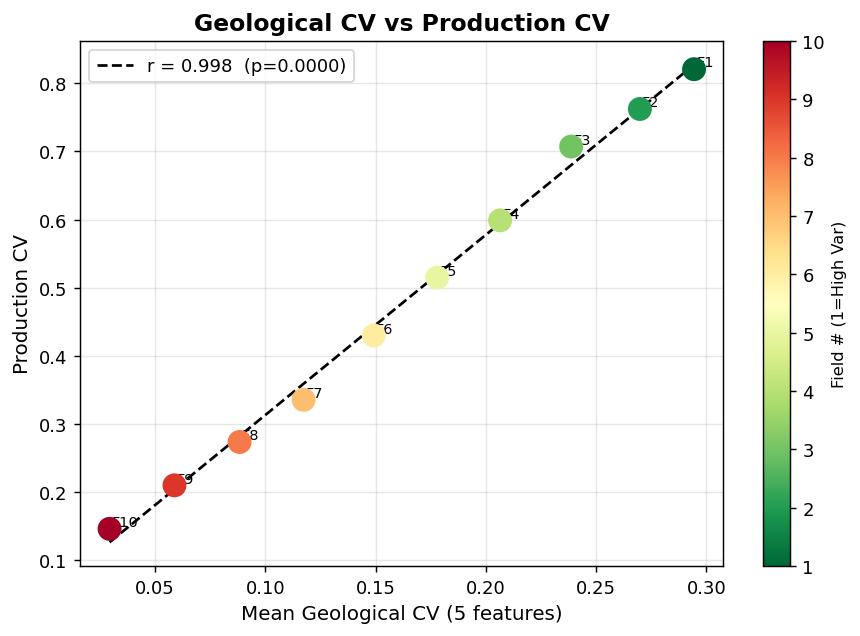

Pearson r = 0.998,  R2 = 0.996,  p = 0.00000


In [14]:
geo_feats = ["Structural_Depth_ft", "Isopach_ft", "GammaRay_API",
              "Resistivity_ohmm", "Porosity_frac"]
geo_cv, prod_cv = [], []
for i in range(1, 11):
    sub = df[df["Field_Variability_Rank"] == i]
    gcv = np.mean([sub[f].std() / sub[f].mean() for f in geo_feats])
    pcv = sub["Oil_Production_BOPD"].std() / sub["Oil_Production_BOPD"].mean()
    geo_cv.append(gcv)
    prod_cv.append(pcv)

geo_cv  = np.array(geo_cv)
prod_cv = np.array(prod_cv)
slope, intercept, r, p, _ = stats.linregress(geo_cv, prod_cv)

fig, ax = plt.subplots(figsize=(7, 5))
sc = ax.scatter(geo_cv, prod_cv, c=range(1, 11), cmap="RdYlGn_r", s=150, zorder=5)
x_fit = np.linspace(geo_cv.min(), geo_cv.max(), 100)
ax.plot(x_fit, slope * x_fit + intercept, "k--", lw=1.5,
        label="r = {:.3f}  (p={:.4f})".format(r, p))
for i, (gx, py) in enumerate(zip(geo_cv, prod_cv)):
    ax.annotate("F{}".format(i + 1), (gx + 0.001, py + 0.004), fontsize=8)
plt.colorbar(sc, ax=ax, label="Field # (1=High Var)")
ax.set_xlabel("Mean Geological CV (5 features)", fontsize=11)
ax.set_ylabel("Production CV", fontsize=11)
ax.set_title("Geological CV vs Production CV", fontsize=13, fontweight="bold")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
print("Pearson r = {:.3f},  R2 = {:.3f},  p = {:.5f}".format(r, r**2, p))


## 10. Export to CSV

In [15]:
df.to_csv("geological_map_dataset.csv", index=False)
print("Saved {:,} rows to geological_map_dataset.csv".format(len(df)))
df.groupby("Field")[features].describe().T.round(2)


Saved 100,000 rows to geological_map_dataset.csv


Field                      Field_01  Field_02  Field_03  Field_04  Field_05  \
Structural_Depth_ft count  10000.00  10000.00  10000.00  10000.00  10000.00   
                    mean    9000.00   9000.00   9000.00   9000.00   9000.00   
                    std     1080.05    972.05    864.04    756.04    648.03   
                    min     5973.10   5717.90   5869.90   5198.50   7021.90   
                    25%     8264.30   8346.45   8405.80   8482.33   8555.78   
                    50%     9013.30   8996.15   8995.60   9026.55   8970.70   
                    75%     9726.82   9630.78   9607.30   9535.40   9427.45   
                    max    13043.70  12442.60  11319.00  11303.70  11195.10   
Isopach_ft          count  10000.00  10000.00  10000.00  10000.00  10000.00   
                    mean      80.10     80.03     80.02     80.00     80.00   
                    std       27.70     25.12     22.32     19.60     16.80   
                    min        5.00      5.00      5.00      8.80     24.70   
                    25%       62.00     63.10     65.90     66.70     68.60   
                    50%       80.40     80.40     80.80     79.60     79.70   
                    75%       99.50     97.50     95.30     93.30     91.90   
                    max      161.50    163.30    149.80    141.10    134.20   
GammaRay_API        count  10000.00  10000.00  10000.00  10000.00  10000.00   
                    mean      45.05     45.01     45.01     45.00     45.00   
                    std       13.36     12.13     10.77      9.45      8.10   
                    min       10.00     10.00     10.00     16.20     20.00   
                    25%       36.00     36.60     38.00     38.60     39.40   
                    50%       45.40     44.70     44.90     45.40     45.00   
                    75%       54.10     53.30     52.00     51.60     50.40   
                    max       89.40     90.90     82.10     73.60     74.40   
Resistivity_ohmm    count  10000.00  10000.00  10000.00  10000.00  10000.00   
                    mean      16.58     16.30     16.02     15.76     15.56   
                    std        7.62      7.05      6.07      5.01      4.32   
                    min        3.91      3.84      4.82      5.68      6.82   
                    25%       11.06     11.50     11.76     12.26     12.51   
                    50%       15.19     15.07     14.91     15.00     14.97   
                    75%       20.26     19.47     19.09     18.48     17.88   
                    max       53.15     63.66     55.35     38.70     35.33   
Porosity_frac       count  10000.00  10000.00  10000.00  10000.00  10000.00   
                    mean       0.18      0.18      0.18      0.18      0.18   
                    std        0.05      0.04      0.04      0.03      0.03   
                    min        0.04      0.03      0.04      0.08      0.09   
                    25%        0.15      0.15      0.16      0.16      0.16   
                    50%        0.18      0.18      0.18      0.18      0.18   
                    75%        0.21      0.21      0.20      0.20      0.20   
                    max        0.31      0.31      0.30      0.28      0.26   
Oil_Production_BOPD count  10000.00  10000.00  10000.00  10000.00  10000.00   
                    mean     267.63    263.47    257.79    256.45    252.05   
                    std      219.65    200.85    182.29    153.58    129.78   
                    min       10.00     10.00     10.00     10.00     10.00   
                    25%      120.80    129.10    140.40    148.38    161.50   
                    50%      211.15    220.20    223.15    220.75    227.00   
                    75%      343.32    346.62    330.30    330.75    321.12   
                    max     2136.40   2902.60   2830.80   1186.40   1546.60   

Field                      Field_06  Field_07  Field_08  Field_09  Field_10  
Structural_Depth_ft count  10000.00  10000.00  100